In [1]:
import os
import glob
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
from skimage.filters import threshold_otsu
from skimage.feature import graycomatrix, graycoprops
from scipy import ndimage
from scipy.stats import skew, kurtosis
from sklearn.mixture import GaussianMixture

In [2]:
inv = pd.read_csv("inventaire_oasis2.csv")
tissue_3d = pd.read_csv("biomarkers_tissue_volumes.csv")
print(f"{len(inv)} sessions dans l'inventaire, {len(tissue_3d)} avec biomarqueurs 3D.")

373 sessions dans l'inventaire, 373 avec biomarqueurs 3D.


In [3]:

def load_averaged_volume(subject_path):
    img_files = sorted(glob.glob(os.path.join(subject_path, "**", "mpr-*.nifti.img"), recursive=True))
    if not img_files:
        raise FileNotFoundError(f"Aucun mpr-*.img trouvé dans {subject_path}")
    volumes = [np.squeeze(nib.load(f).get_fdata()) for f in img_files]
    header = nib.load(img_files[0]).header
    return np.mean(volumes, axis=0), header.get_zooms()[:3]
 
 
def simple_skull_strip_2d(slice_2d):
    """Version 2D, rapide : ne traite qu'une coupe, pas tout le volume."""
    threshold = threshold_otsu(slice_2d[slice_2d > 0])
    mask = slice_2d > threshold
    labeled, n = ndimage.label(mask)
    if n > 0:
        sizes = ndimage.sum(mask, labeled, range(1, n + 1))
        largest = np.argmax(sizes) + 1
        mask = labeled == largest
    return ndimage.binary_dilation(mask, iterations=2)
 
 
def segment_tissues_2d(slice_2d, mask_2d, n_classes=3):
    """GMM 2D : ajuste sur ~30k pixels au lieu de ~1M+ voxels (rapide)."""
    pixels = slice_2d[mask_2d].reshape(-1, 1)
    gmm = GaussianMixture(n_components=n_classes, random_state=0).fit(pixels)
    labels_flat = gmm.predict(pixels)
    order = np.argsort(gmm.means_.flatten())
    remap = {old: new for new, old in enumerate(order)}
    labels_flat = np.array([remap[l] for l in labels_flat])
    seg = np.zeros(slice_2d.shape, dtype=int)
    seg[mask_2d] = labels_flat + 1
    return seg

In [4]:
def central_axial_slice(volume):
    z = volume.shape[2] // 2
    return volume[:, :, z]

In [5]:
def compute_slice_areas(seg_slice, pixel_dims):
    pixel_area_mm2 = pixel_dims[0] * pixel_dims[1]
    label_names = {1: "csf", 2: "gray_matter", 3: "white_matter"}
    areas = {}
    for label, name in label_names.items():
        areas[f"{name}_area_cm2"] = np.sum(seg_slice == label) * pixel_area_mm2 / 100.0
    return areas

In [6]:
def compute_asymmetry(seg_slice):
    mid = seg_slice.shape[0] // 2
    left, right = seg_slice[:mid, :], seg_slice[mid:, :]
 
    def asym_index(label):
        l, r = np.sum(left == label), np.sum(right == label)
        total = l + r
        return (l - r) / total if total > 0 else np.nan
 
    return {
        "asymmetry_gray_matter": asym_index(2),
        "asymmetry_white_matter": asym_index(3),
    }

In [7]:
def compute_radiomic_features(volume_slice, brain_mask):
    brain_pixels = volume_slice[brain_mask > 0]
    if brain_pixels.size == 0:
        return {}
    features = {
        "intensity_mean": float(np.mean(brain_pixels)),
        "intensity_std": float(np.std(brain_pixels)),
        "intensity_skew": float(skew(brain_pixels)),
        "intensity_kurtosis": float(kurtosis(brain_pixels)),
    }
    norm = volume_slice.copy()
    norm[brain_mask == 0] = 0
    norm = (255 * (norm - norm.min()) / (np.ptp(norm) + 1e-8)).astype(np.uint8)
    glcm = graycomatrix(norm, distances=[1], angles=[0], levels=256, symmetric=True, normed=True)
    features["texture_contrast"] = float(graycoprops(glcm, "contrast")[0, 0])
    features["texture_homogeneity"] = float(graycoprops(glcm, "homogeneity")[0, 0])
    features["texture_energy"] = float(graycoprops(glcm, "energy")[0, 0])
    return features

Sujet : OAS2_0001_MR1
Aires 2D (cm²) : {'csf_area_cm2': np.float64(27.39), 'gray_matter_area_cm2': np.float64(32.08), 'white_matter_area_cm2': np.float64(9.7)}
Asymétrie : {'asymmetry_gray_matter': np.float64(0.23316708229426433), 'asymmetry_white_matter': np.float64(-0.02268041237113402)}
Radiomique : {'intensity_mean': 850.8344658088766, 'intensity_std': 557.448184834107, 'intensity_skew': 1.0435350664574832, 'intensity_kurtosis': 1.2074990295506574, 'texture_contrast': 96.17359068627452, 'texture_homogeneity': 0.8943085671622671, 'texture_energy': 0.8876404568997658}


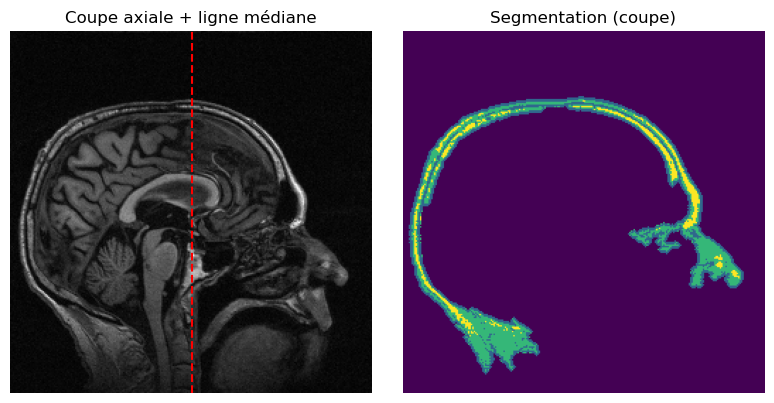

In [8]:
example = inv[inv["has_any_volume"]].iloc[0]
volume, voxel_dims = load_averaged_volume(example["path"])
vol_slice = central_axial_slice(volume)
mask_slice = simple_skull_strip_2d(vol_slice)
seg_slice = segment_tissues_2d(vol_slice, mask_slice)
 
areas = compute_slice_areas(seg_slice, voxel_dims)
asymmetry = compute_asymmetry(seg_slice)
radiomics = compute_radiomic_features(vol_slice, brain_mask=mask_slice)
 
print("Sujet :", example["subject_id"])
print("Aires 2D (cm²) :", areas)
print("Asymétrie :", asymmetry)
print("Radiomique :", radiomics)
 
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(vol_slice.T, cmap="gray", origin="lower")
axes[0].axvline(vol_slice.shape[0] // 2, color="red", linestyle="--")
axes[0].set_title("Coupe axiale + ligne médiane")
axes[1].imshow(seg_slice.T, cmap="viridis", origin="lower")
axes[1].set_title("Segmentation (coupe)")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

In [9]:
def build_2d_biomarker_table(inv_df):
    rows = []
    subset = inv_df[inv_df["has_any_volume"]].reset_index(drop=True)
    n = len(subset)
    for i, row in subset.iterrows():
        try:
            volume, voxel_dims = load_averaged_volume(row["path"])
            vol_slice = central_axial_slice(volume)
            # segmentation directement sur la coupe 2D (beaucoup plus rapide
            # que segmenter tout le volume 3D pour n'en garder qu'une tranche)
            mask_slice = simple_skull_strip_2d(vol_slice)
            seg_slice = segment_tissues_2d(vol_slice, mask_slice)
 
            entry = {"subject_id": row["subject_id"]}
            entry.update(compute_slice_areas(seg_slice, voxel_dims))
            entry.update(compute_asymmetry(seg_slice))
            entry.update(compute_radiomic_features(vol_slice, brain_mask=mask_slice))
            rows.append(entry)
        except Exception as e:
            print(f"Erreur pour {row['subject_id']} : {e}")
        if (i + 1) % 20 == 0 or (i + 1) == n:
            print(f"  {i + 1}/{n} sessions traitées...")
    return pd.DataFrame(rows)
 
 
biomarkers_2d = build_2d_biomarker_table(inv)
print(f"\n{len(biomarkers_2d)} sessions traitées avec succès.")
biomarkers_2d.to_csv("biomarkers_2D.csv", index=False)
print("Sauvegardé : biomarkers_2D.csv")
biomarkers_2d.head()

  20/373 sessions traitées...
  40/373 sessions traitées...
  60/373 sessions traitées...
  80/373 sessions traitées...
  100/373 sessions traitées...
  120/373 sessions traitées...
  140/373 sessions traitées...
  160/373 sessions traitées...
  180/373 sessions traitées...
  200/373 sessions traitées...
  220/373 sessions traitées...
  240/373 sessions traitées...
  260/373 sessions traitées...
  280/373 sessions traitées...
  300/373 sessions traitées...
  320/373 sessions traitées...
  340/373 sessions traitées...
  360/373 sessions traitées...
  373/373 sessions traitées...

373 sessions traitées avec succès.
Sauvegardé : biomarkers_2D.csv


,subject_id,csf_area_cm2,gray_matter_area_cm2,white_matter_area_cm2,asymmetry_gray_matter,asymmetry_white_matter,intensity_mean,intensity_std,intensity_skew,intensity_kurtosis,texture_contrast,texture_homogeneity,texture_energy
0,OAS2_0001_MR1,27.39,32.08,9.70,0.233167,-0.022680,850.834466,557.448185,1.043535,1.207499,96.173591,0.894309,0.887640
1,OAS2_0001_MR2,78.86,84.05,19.56,0.284949,0.098160,833.889315,426.762229,1.026753,1.852673,150.135172,0.730710,0.708915
2,OAS2_0002_MR1,32.55,18.47,19.04,0.451002,0.474790,770.276977,393.958619,0.479970,-0.673023,76.206403,0.894760,0.887716
3,OAS2_0002_MR2,14.56,32.12,6.81,-0.125778,-0.171806,929.170125,402.700876,1.065313,4.329653,29.009161,0.922462,0.914110
4,OAS2_0002_MR3,30.01,27.09,12.56,0.318568,0.221338,1176.311944,771.538278,0.751300,-0.175039,117.975888,0.894236,0.887808
